# Prediction de defauts optiques — Pipeline final

**Mission :** predire la distorsion optique (12 points `value_center_k1` a `value_center_k12`) a partir de mesures de deformation physique de surface sur des composants automobiles transparents (pare-brise, phare...). La valeur 0 represente une surface / une optique parfaitement conforme.

**Pipeline conforme a la feuille de route validee avec l'encadrant :**
1. Exploration et pretraitement (EDA) — valeurs manquantes / aberrantes
2. Standardisation des variables X (`StandardScaler`)
3. Strategie de validation — split train (80%) / validation (20%)
4. Entrainement et benchmark — Random Forest vs Gradient Boosting
5. Optimisation des hyperparametres du modele gagnant
6. Export des predictions sur le jeu de test aveugle (`INDUSTRIAL_AI_Infer.pkl`)

**Strategie d'evaluation :**
- Metrique principale : coefficient de determination **R2** (global + par point k1-k12)
- Metrique metier complementaire : **MAE** (erreur absolue moyenne, dans l'unite reelle du capteur)

> Contrairement a la premiere version (un seul modele multi-sortie captant les correlations entre points), cette version suit fidelement la feuille de route de l'encadrant : un benchmark explicite RF vs Gradient Boosting, une standardisation StandardScaler, un split 80/20 simple, puis une optimisation d'hyperparametres du modele gagnant.


In [ ]:
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import ParameterSampler, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

PATH_TRAIN = "INDUSTRIAL_AI_TrainValTest.pkl"   # donnees labellisees (entrainement + validation)
PATH_INFER = "INDUSTRIAL_AI_Infer.pkl"          # jeu de test aveugle (a predire, ordre a respecter)

ARTIFACTS_DIR = "artifacts"                      # consomme ensuite par l'appli Streamlit
os.makedirs(ARTIFACTS_DIR, exist_ok=True)


In [ ]:
# Detection de l'environnement (Google Colab ou local)
try:
    from google.colab import files as colab_files
    IN_COLAB = True
    print("Environnement : Google Colab")
except ImportError:
    IN_COLAB = False
    print("Environnement : local (Jupyter / VS Code)")

Environnement : Google Colab


## 1. Chargement des donnees

### Upload des donnees (Google Colab uniquement)

Le systeme de fichiers de Colab est **temporaire** : a chaque nouvelle
session, les fichiers doivent etre re-uploades (rien n'est conserve d'une
session a l'autre, contrairement a un poste local).

Executez la cellule suivante puis selectionnez **les deux fichiers** :
`INDUSTRIAL_AI_TrainValTest.pkl` et `INDUSTRIAL_AI_Infer.pkl`. Ils doivent
garder exactement ces noms (ce sont ceux attendus par `PATH_TRAIN` /
`PATH_INFER` definis plus haut).

> Si vous preferez ne pas re-uploader a chaque fois, l'alternative est de
> monter votre Google Drive (`from google.colab import drive;
> drive.mount('/content/drive')`) et de placer les `.pkl` dedans une bonne
> fois pour toutes — mais l'upload direct ci-dessous est plus simple pour
> un usage ponctuel.

In [ ]:
import os
import re

if IN_COLAB:
    print("Selectionnez INDUSTRIAL_AI_TrainValTest.pkl et INDUSTRIAL_AI_Infer.pkl :")
    uploaded = colab_files.upload()
    print("\nFichiers recus :", list(uploaded.keys()))

    def _resoudre_fichier(nom_attendu, noms_recus):
        """Colab ajoute un suffixe (' (1)', ' (2)'...) si un fichier du meme nom
        existe deja dans la session (ex: la cellule a ete executee 2 fois).
        On retrouve le bon fichier malgre le suffixe et on le renomme sur
        disque pour que le reste du notebook (PATH_TRAIN / PATH_INFER)
        fonctionne sans rien changer d'autre."""
        if nom_attendu in noms_recus:
            return
        base, ext = os.path.splitext(nom_attendu)
        motif = re.compile(rf"^{re.escape(base)}( \(\d+\))?{re.escape(ext)}$")
        for nom in noms_recus:
            if motif.match(nom):
                os.replace(nom, nom_attendu)
                print(f"  '{nom}' -> renomme en '{nom_attendu}'")
                return
        raise AssertionError(
            f"Fichier manquant : {nom_attendu} (verifiez que vous avez bien "
            f"selectionne ce fichier lors de l'upload)"
        )

    for required in (PATH_TRAIN, PATH_INFER):
        _resoudre_fichier(required, list(uploaded.keys()))

    print(f"\nOK : '{PATH_TRAIN}' et '{PATH_INFER}' sont prets a etre charges.")
else:
    print("Environnement local : les fichiers doivent deja etre dans le dossier de travail.")

Selectionnez INDUSTRIAL_AI_TrainValTest.pkl et INDUSTRIAL_AI_Infer.pkl :


Saving INDUSTRIAL_AI_Infer.pkl to INDUSTRIAL_AI_Infer.pkl
Saving INDUSTRIAL_AI_TrainValTest.pkl to INDUSTRIAL_AI_TrainValTest.pkl

Fichiers recus : ['INDUSTRIAL_AI_Infer.pkl', 'INDUSTRIAL_AI_TrainValTest.pkl']

OK : 'INDUSTRIAL_AI_TrainValTest.pkl' et 'INDUSTRIAL_AI_Infer.pkl' sont prets a etre charges.


In [ ]:
train = pd.read_pickle(PATH_TRAIN)
infer = pd.read_pickle(PATH_INFER)

Y_COLS = [c for c in train.columns if c.startswith("value_center_k")]
X_COLS = [c for c in train.columns if c not in Y_COLS]

print(f"Train/Val/Test labellise : {train.shape}  ({len(X_COLS)} variables X, {len(Y_COLS)} cibles Y)")
print(f"Jeu de test aveugle (infer) : {infer.shape}")

assert set(X_COLS).issubset(set(infer.columns)), "Les colonnes X du jeu infer ne correspondent pas au train."
Y_COLS


Train/Val/Test labellise : (5414, 41)  (29 variables X, 12 cibles Y)
Jeu de test aveugle (infer) : (4413, 29)


['value_center_k1',
 'value_center_k2',
 'value_center_k3',
 'value_center_k4',
 'value_center_k5',
 'value_center_k6',
 'value_center_k7',
 'value_center_k8',
 'value_center_k9',
 'value_center_k10',
 'value_center_k11',
 'value_center_k12']

## 2. Exploration et pretraitement (EDA)

### 2.1 Valeurs manquantes


Taux de valeurs manquantes - variables X (top 10) :
s39    0.33 %
s40    0.33 %
s41    0.33 %
v92     0.0 %
v93     0.0 %
v94     0.0 %
v95     0.0 %
v96     0.0 %
v97     0.0 %
v98     0.0 %
dtype: object

Taux de valeurs manquantes - cibles Y :
value_center_k2     0.28 %
value_center_k3     0.11 %
value_center_k1     0.09 %
value_center_k6     0.09 %
value_center_k4     0.07 %
value_center_k5     0.07 %
value_center_k10    0.02 %
value_center_k7      0.0 %
value_center_k8      0.0 %
value_center_k9      0.0 %
value_center_k11     0.0 %
value_center_k12     0.0 %
dtype: object


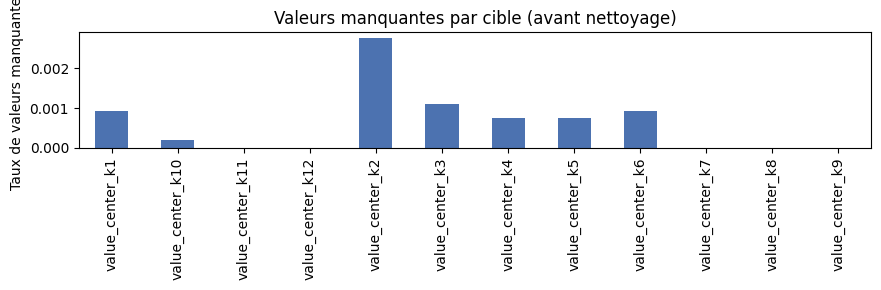

In [ ]:
missing_X = train[X_COLS].isna().mean().sort_values(ascending=False)
missing_Y = train[Y_COLS].isna().mean().sort_values(ascending=False)

print("Taux de valeurs manquantes - variables X (top 10) :")
print((missing_X.head(10) * 100).round(2).astype(str) + " %")
print("\nTaux de valeurs manquantes - cibles Y :")
print((missing_Y * 100).round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(9, 3))
missing_Y.sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Taux de valeurs manquantes")
ax.set_title("Valeurs manquantes par cible (avant nettoyage)")
plt.tight_layout()
plt.show()


### 2.2 Valeurs aberrantes (outliers capteur)

L'objectif metier est de s'approcher de 0 : une distorsion optique realiste reste dans une plage bornee autour de 0. Une valeur tres eloignee de cette plage correspond generalement a une erreur de mesure du capteur (glitch), pas a un vrai defaut physique — on l'exclut donc de l'apprentissage (mise a `NaN`) plutot que de la laisser polluer le modele.

Le seuil ci-dessous est un point de depart a **confirmer visuellement** sur les histogrammes (a ajuster si besoin selon ce que montrent vos vraies donnees).


Statistiques descriptives des cibles Y (avant nettoyage) :
                    mean    std    min     max
value_center_k1   12.356  1.805  5.761   18.69
value_center_k2   10.219  1.820  4.352   17.62
value_center_k3   10.578  3.020  4.753  143.20
value_center_k4   10.271  2.364  5.014   24.51
value_center_k5   11.913  2.795  6.959  147.90
value_center_k6   12.345  2.309  5.144   19.19
value_center_k7   12.452  3.251  6.156  141.30
value_center_k8   13.443  2.465  5.488   22.16
value_center_k9   10.479  2.477  5.872  146.70
value_center_k10  10.179  2.199  4.792   17.86
value_center_k11  11.927  2.439  6.727   18.96
value_center_k12  12.609  2.721  4.982   20.33


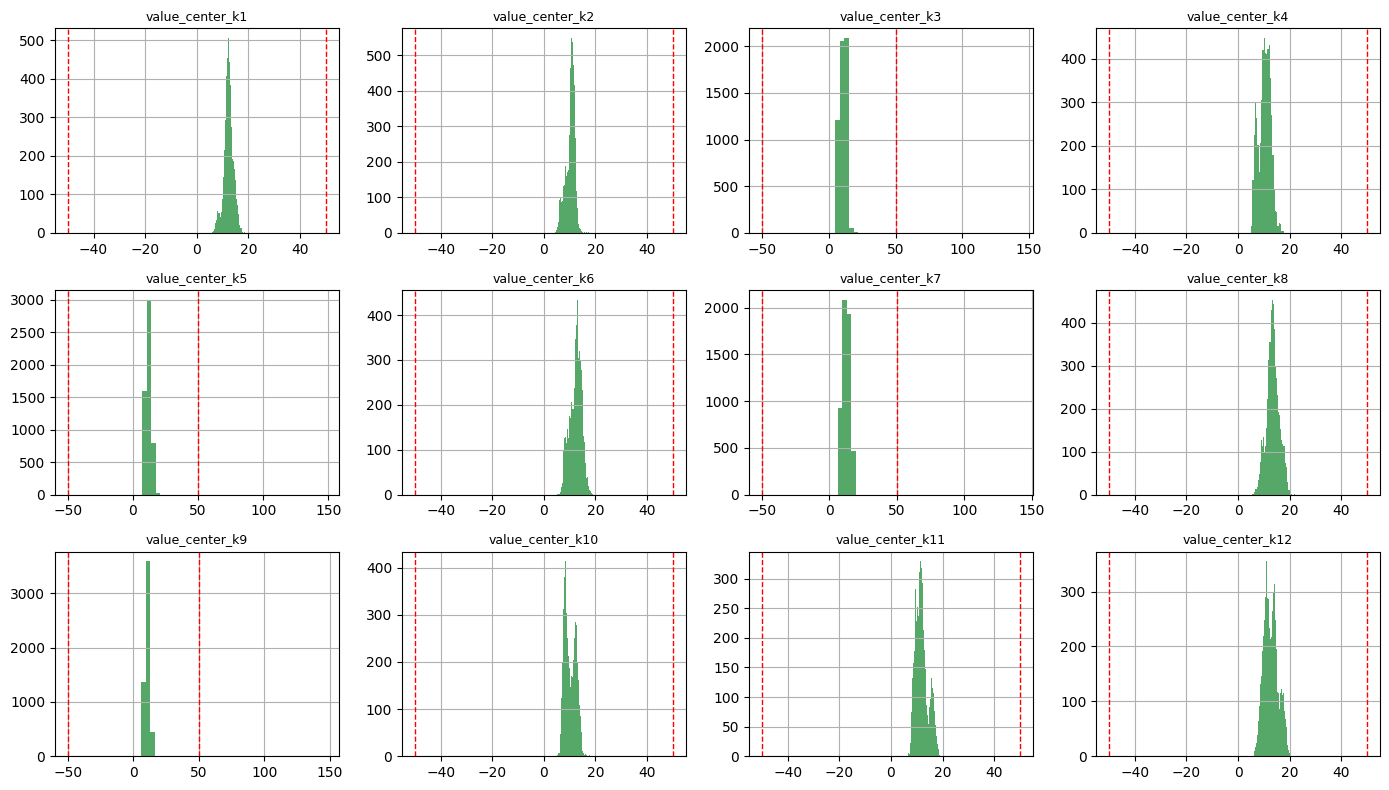


Valeurs |Y| > 50 detectees comme aberrantes (par cible) :
value_center_k3    1
value_center_k5    1
value_center_k7    1
value_center_k9    1
dtype: int64


In [ ]:
print("Statistiques descriptives des cibles Y (avant nettoyage) :")
print(train[Y_COLS].describe().T[["mean", "std", "min", "max"]].round(3))

OUTLIER_Y_MAX = 50  # seuil metier (valeur absolue) — a confirmer/ajuster selon les histogrammes

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, col in zip(axes.ravel(), Y_COLS):
    train[col].hist(bins=40, ax=ax, color="#55A868")
    ax.axvline(OUTLIER_Y_MAX, color="red", linestyle="--", linewidth=1)
    ax.axvline(-OUTLIER_Y_MAX, color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

n_outliers = (train[Y_COLS].abs() > OUTLIER_Y_MAX).sum()
print(f"\nValeurs |Y| > {OUTLIER_Y_MAX} detectees comme aberrantes (par cible) :")
print(n_outliers[n_outliers > 0] if n_outliers.sum() > 0 else "Aucune valeur aberrante detectee au seuil actuel.")

train[Y_COLS] = train[Y_COLS].mask(train[Y_COLS].abs() > OUTLIER_Y_MAX)


## 3. Strategie de validation : split train (80%) / validation (20%)

Le split est effectue une seule fois sur l'ensemble labellise. L'imputation (mediane) et la standardisation (`StandardScaler`) sont ensuite ajustees **uniquement sur le train** pour eviter toute fuite d'information vers la validation.


In [ ]:
train_part, val_part = train_test_split(train, test_size=0.20, random_state=RANDOM_STATE)
print(f"Entrainement : {train_part.shape[0]} lignes ({train_part.shape[0] / len(train):.0%})")
print(f"Validation   : {val_part.shape[0]} lignes ({val_part.shape[0] / len(train):.0%})")

# Imputation des valeurs manquantes (mediane), ajustee sur le train uniquement
imputer = SimpleImputer(strategy="median").fit(train_part[X_COLS])
Xtr = pd.DataFrame(imputer.transform(train_part[X_COLS]), columns=X_COLS, index=train_part.index)
Xval = pd.DataFrame(imputer.transform(val_part[X_COLS]), columns=X_COLS, index=val_part.index)

# Standardisation, ajustee sur le train uniquement
scaler = StandardScaler().fit(Xtr)
Xtr_s = pd.DataFrame(scaler.transform(Xtr), columns=X_COLS, index=Xtr.index)
Xval_s = pd.DataFrame(scaler.transform(Xval), columns=X_COLS, index=Xval.index)


Entrainement : 4331 lignes (80%)
Validation   : 1083 lignes (20%)


## 4. Entrainement et benchmark : Random Forest vs Gradient Boosting

Chaque cible (`k1`...`k12`) a son propre pattern de valeurs manquantes : on entraine donc, pour chaque algorithme, **un modele independant par cible** (12 modeles), chacun uniquement sur les lignes ou cette cible est renseignee. Les deux algorithmes sont compares sur le **meme split** train/validation pour une comparaison equitable.


In [ ]:
def make_rf(**kwargs):
    params = dict(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    params.update(kwargs)
    return RandomForestRegressor(**params)


def make_gb(**kwargs):
    params = dict(n_estimators=300, random_state=RANDOM_STATE)
    params.update(kwargs)
    return GradientBoostingRegressor(**params)


def evaluate(model_factory, **kwargs):
    """Entraine un modele independant par cible (k1..k12) et retourne R2/MAE par cible (validation)."""
    r2s, maes = [], []
    for col in Y_COLS:
        m_tr = train_part[col].notna().values
        m_val = val_part[col].notna().values
        model = model_factory(**kwargs).fit(Xtr_s[m_tr], train_part.loc[m_tr, col])
        pred = model.predict(Xval_s[m_val])
        y_true = val_part.loc[m_val, col]
        r2s.append(r2_score(y_true, pred))
        maes.append(mean_absolute_error(y_true, pred))
    return np.array(r2s), np.array(maes)


                                Random Forest  Gradient Boosting
R2 global (moyenne 12 cibles)          0.7402             0.7131
MAE global (moyenne 12 cibles)         0.8395             0.9004


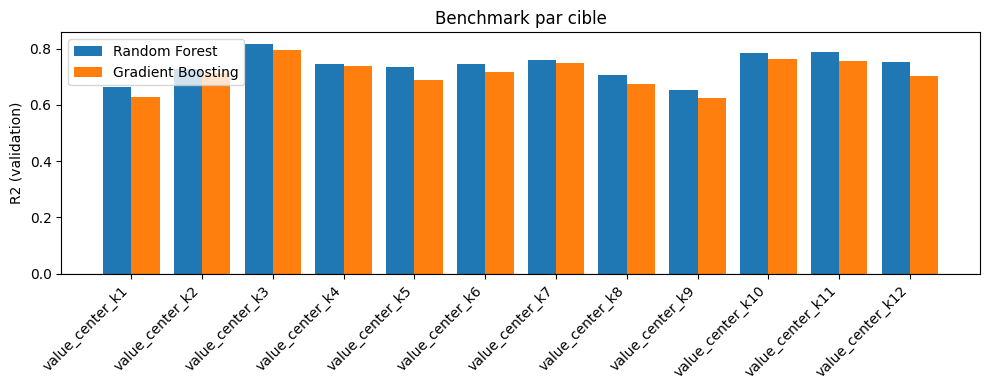


>>> Modele retenu pour l'optimisation : Random Forest


In [ ]:
r2_rf, mae_rf = evaluate(make_rf)
r2_gb, mae_gb = evaluate(make_gb)

benchmark = pd.DataFrame(
    {
        "Random Forest": [r2_rf.mean(), mae_rf.mean()],
        "Gradient Boosting": [r2_gb.mean(), mae_gb.mean()],
    },
    index=["R2 global (moyenne 12 cibles)", "MAE global (moyenne 12 cibles)"],
)
print(benchmark.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(Y_COLS))
ax.bar(x - 0.2, r2_rf, width=0.4, label="Random Forest")
ax.bar(x + 0.2, r2_gb, width=0.4, label="Gradient Boosting")
ax.set_xticks(x)
ax.set_xticklabels(Y_COLS, rotation=45, ha="right")
ax.set_ylabel("R2 (validation)")
ax.set_title("Benchmark par cible")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

WINNER = "Random Forest" if r2_rf.mean() >= r2_gb.mean() else "Gradient Boosting"
WINNER_FACTORY = make_rf if WINNER == "Random Forest" else make_gb
print(f"\n>>> Modele retenu pour l'optimisation : {WINNER}")


## 5. Optimisation des hyperparametres du modele gagnant

Recherche aleatoire (equivalent a `RandomizedSearchCV`, adaptee au fait que chaque cible a son propre modele/masque) : on tire des combinaisons d'hyperparametres, on entraine les 12 modeles pour chacune, et on retient celle qui **maximise le R2 moyen sur la validation** (coherent avec la metrique principale du projet).


In [ ]:
PARAM_GRID_RF = dict(
    n_estimators=[200, 300, 500],
    max_depth=[None, 6, 10, 16],
    min_samples_leaf=[1, 2, 4, 8],
    max_features=["sqrt", "log2", 0.6, 0.8],
)
PARAM_GRID_GB = dict(
    n_estimators=[150, 250, 400],
    learning_rate=[0.02, 0.05, 0.1],
    max_depth=[2, 3, 4],
    subsample=[0.7, 0.85, 1.0],
    min_samples_leaf=[5, 10, 20],
)
PARAM_GRID = PARAM_GRID_RF if WINNER == "Random Forest" else PARAM_GRID_GB

N_ITER = 15  # nombre de combinaisons testees ; augmenter si le temps de calcul le permet
candidates = list(ParameterSampler(PARAM_GRID, n_iter=N_ITER, random_state=RANDOM_STATE))

best_score, best_params = -np.inf, None
search_log = []
for params in candidates:
    r2s, _ = evaluate(WINNER_FACTORY, **params)
    score = r2s.mean()
    search_log.append({**params, "R2_moyen": score})
    if score > best_score:
        best_score, best_params = score, params

search_log = pd.DataFrame(search_log).sort_values("R2_moyen", ascending=False)
print("Top 5 combinaisons :")
print(search_log.head(5).round(4))

baseline = r2_rf.mean() if WINNER == "Random Forest" else r2_gb.mean()
print(f"\nMeilleurs hyperparametres : {best_params}")
print(f"R2 moyen (validation) apres optimisation : {best_score:.4f}  (vs {baseline:.4f} avant optimisation)")


Top 5 combinaisons :
   n_estimators  min_samples_leaf max_features  max_depth  R2_moyen
1           300                 2          0.8       10.0    0.7369
8           300                 2         log2        NaN    0.7338
6           200                 2         log2        NaN    0.7327
5           200                 8          0.6       16.0    0.7281
0           200                 8          0.8        NaN    0.7267

Meilleurs hyperparametres : {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 10}
R2 moyen (validation) apres optimisation : 0.7369  (vs 0.7402 avant optimisation)


## 6. Evaluation detaillee du modele final (validation)

                      R2     MAE
cible                           
value_center_k1   0.6386  0.8028
value_center_k2   0.7342  0.7039
value_center_k3   0.8161  0.7821
value_center_k4   0.7410  0.9269
value_center_k5   0.7339  0.8287
value_center_k6   0.7370  0.9095
value_center_k7   0.7613  0.9840
value_center_k8   0.7045  0.9945
value_center_k9   0.6482  0.7371
value_center_k10  0.7854  0.7504
value_center_k11  0.7905  0.8058
value_center_k12  0.7516  0.9453
GLOBAL (moyenne)  0.7369  0.8476


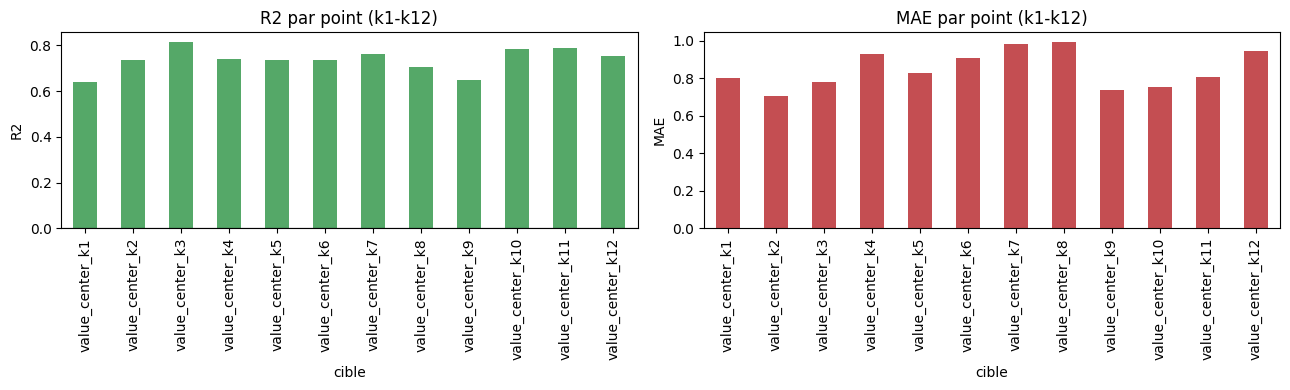

In [ ]:
r2_final, mae_final = evaluate(WINNER_FACTORY, **best_params)
results = pd.DataFrame({"cible": Y_COLS, "R2": r2_final, "MAE": mae_final}).set_index("cible")
results.loc["GLOBAL (moyenne)"] = [r2_final.mean(), mae_final.mean()]
print(results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
results.iloc[:-1]["R2"].plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("R2 par point (k1-k12)")
axes[0].set_ylabel("R2")

results.iloc[:-1]["MAE"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("MAE par point (k1-k12)")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()


## 7. Modele final & export des predictions (jeu de test aveugle)

Le modele final est reentraine avec les hyperparametres optimises, sur **l'ensemble des donnees labellisees** (train + validation) afin de maximiser l'information disponible avant de predire le jeu de test aveugle. L'ordre des lignes du fichier `infer` est preserve.


In [ ]:
# Imputer + scaler finaux, reajustes sur l'ensemble des donnees labellisees
imputer_final = SimpleImputer(strategy="median").fit(train[X_COLS])
Xall = pd.DataFrame(imputer_final.transform(train[X_COLS]), columns=X_COLS, index=train.index)
scaler_final = StandardScaler().fit(Xall)
Xall_s = pd.DataFrame(scaler_final.transform(Xall), columns=X_COLS, index=train.index)

Xinf = pd.DataFrame(imputer_final.transform(infer[X_COLS]), columns=X_COLS, index=infer.index)
Xinf_s = pd.DataFrame(scaler_final.transform(Xinf), columns=X_COLS, index=infer.index)

final_models = {}
preds = {}
for col in Y_COLS:
    m = train[col].notna().values
    model = WINNER_FACTORY(**best_params).fit(Xall_s[m], train.loc[m, col])
    final_models[col] = model
    preds[col] = model.predict(Xinf_s)

pred_df = pd.DataFrame(preds)[Y_COLS]
assert len(pred_df) == len(infer), "Le nombre de lignes doit correspondre au jeu de test aveugle."
assert pred_df.isna().sum().sum() == 0, "Aucune prediction ne doit etre manquante."

OUTPUT_CSV = "predictions_Y_v3.csv"
pred_df.to_csv(OUTPUT_CSV, index=False)
print(f"Fichier ecrit : {OUTPUT_CSV}  {pred_df.shape}")
pred_df.head()


Fichier ecrit : predictions_Y_v3.csv  (4413, 12)


,value_center_k1,value_center_k2,value_center_k3,value_center_k4,value_center_k5,value_center_k6,value_center_k7,value_center_k8,value_center_k9,value_center_k10,value_center_k11,value_center_k12
0,8.778609,6.111909,8.698998,9.002948,11.082712,10.247206,8.724852,9.264673,8.933605,8.115350,10.199579,9.092333
1,8.901689,6.589256,7.765875,9.479186,11.558206,9.226980,8.530672,10.003868,8.655228,8.987519,9.507047,9.711886
2,8.447736,6.716481,7.698556,9.976515,12.083042,10.112254,8.200507,11.079824,8.649489,9.209849,8.994587,10.014200
3,8.316705,6.642074,7.902602,10.108515,11.709045,9.929704,8.118969,11.045117,8.853503,9.407631,9.043004,10.055430
4,9.620468,6.494119,8.053647,9.002004,10.402678,9.615626,8.665624,9.702872,7.995894,10.521969,9.796614,9.704426


## 8. Sauvegarde des artefacts (pour l'interface Streamlit)

Ces fichiers sont lus par `app.py` pour presenter le projet sans avoir a relancer l'entrainement.


In [ ]:
joblib.dump(imputer_final, f"{ARTIFACTS_DIR}/imputer.joblib")
joblib.dump(scaler_final, f"{ARTIFACTS_DIR}/scaler.joblib")
joblib.dump(final_models, f"{ARTIFACTS_DIR}/models.joblib")


def _to_jsonable(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    return v


# Tolerance de conformite par defaut, utilisee par l'onglet "Tester une piece"
# de l'appli Streamlit (diagnostic Conforme/Defaut point par point). Valeur de
# depart = mediane reelle de |distorsion| observee (place-holder statistique) ;
# a REMPLACER par la vraie tolerance metier du cahier des charges des qu'elle
# est connue (voir aussi la section 8. Matrice de confusion / TOLERANCE).
TOLERANCE_DEFAULT = float(train[Y_COLS].abs().stack().dropna().median())

metadata = {
    "winner_algo": WINNER,
    "best_params": {k: _to_jsonable(v) for k, v in best_params.items()},
    "x_cols": X_COLS,
    "y_cols": Y_COLS,
    "outlier_y_max": OUTLIER_Y_MAX,
    "tolerance": round(TOLERANCE_DEFAULT, 3),
    "n_train_labelled": int(len(train)),
    "n_infer": int(len(infer)),
    "benchmark": {
        "Random Forest": {"R2": float(r2_rf.mean()), "MAE": float(mae_rf.mean())},
        "Gradient Boosting": {"R2": float(r2_gb.mean()), "MAE": float(mae_gb.mean())},
    },
    "results_per_target": results.reset_index().to_dict(orient="records"),
}
with open(f"{ARTIFACTS_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

pred_df.to_csv(f"{ARTIFACTS_DIR}/predictions.csv", index=False)
infer[X_COLS].reset_index(drop=True).to_csv(f"{ARTIFACTS_DIR}/infer_X.csv", index=False)

print("Artefacts sauvegardes dans le dossier :", ARTIFACTS_DIR)
print(os.listdir(ARTIFACTS_DIR))


Artefacts sauvegardes dans le dossier : artifacts
['imputer.joblib', 'models.joblib', 'scaler.joblib', 'predictions.csv', 'infer_X.csv', 'metadata.json']


## 9. Telechargement des resultats (Google Colab)

Regroupe tout ce qu'il faut pour l'interface Streamlit (`artifacts/`) et le
CSV de predictions dans une seule archive, puis declenche son
telechargement vers votre ordinateur.

**Etapes suivantes une fois le zip telecharge :**
1. Extrayez `resultats_projet.zip`
2. Placez le dossier `artifacts/` a cote de `app.py` (l'interface Streamlit
   fournie precedemment)
3. En local : `pip install -r requirements.txt` puis `streamlit run app.py`

In [ ]:
import shutil
from pathlib import Path

BUNDLE_DIR = Path("bundle_resultats")
if BUNDLE_DIR.exists():
    shutil.rmtree(BUNDLE_DIR)
BUNDLE_DIR.mkdir()

shutil.copytree(ARTIFACTS_DIR, BUNDLE_DIR / "artifacts")
shutil.copy(OUTPUT_CSV, BUNDLE_DIR / OUTPUT_CSV)

zip_path = shutil.make_archive("resultats_projet", "zip", root_dir=BUNDLE_DIR)
print(f"Archive prete : {zip_path}")
print(f"Contenu : artifacts/ (pour Streamlit) + {OUTPUT_CSV} (livrable a l'encadrant)")

if IN_COLAB:
    colab_files.download(zip_path)
else:
    print(f"Environnement local : recuperez directement '{zip_path}' dans le dossier de travail.")

Archive prete : /content/resultats_projet.zip
Contenu : artifacts/ (pour Streamlit) + predictions_Y_v3.csv (livrable a l'encadrant)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 10.Test du model

=== Validation croisee (5-Fold) — modele : Random Forest ===

                 R2_train          R2_val         MAE_val        
                     mean     std    mean     std    mean     std
cible                                                            
value_center_k1    0.7954  0.0064  0.6445  0.0136  0.8105  0.0148
value_center_k10   0.9168  0.0011  0.7886  0.0056  0.7573  0.0109
value_center_k11   0.9089  0.0026  0.7837  0.0142  0.8417  0.0213
value_center_k12   0.9060  0.0025  0.7766  0.0159  0.9212  0.0215
value_center_k2    0.8790  0.0033  0.7483  0.0130  0.6880  0.0177
value_center_k3    0.9159  0.0016  0.8101  0.0079  0.7692  0.0219
value_center_k4    0.8827  0.0011  0.7319  0.0134  0.9042  0.0278
value_center_k5    0.8765  0.0024  0.7319  0.0132  0.8067  0.0204
value_center_k6    0.8833  0.0033  0.7440  0.0090  0.8806  0.0184
value_center_k7    0.9008  0.0020  0.7590  0.0097  1.0027  0.0117
value_center_k8    0.8809  0.0022  0.7203  0.0230  0.9771  0.0188
value_center_k

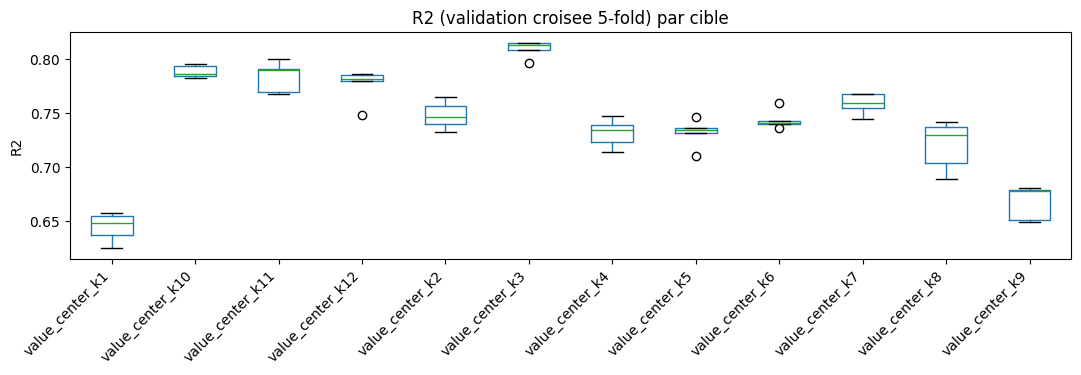

In [ ]:
from sklearn.model_selection import KFold

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_records = []
# Predictions "out-of-fold" (OOF) : chaque ligne est predite par un modele
# qui ne l'a jamais vue a l'entrainement -> utilisees ensuite pour la
# matrice de confusion et le test du Chi-2 (evaluation hors echantillon,
# pas sur les donnees d'entrainement).
oof_pred = {c: pd.Series(index=train.index, dtype=float) for c in Y_COLS}

for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train), start=1):
    tr_df, va_df = train.iloc[tr_idx], train.iloc[va_idx]

    imp_f = SimpleImputer(strategy="median").fit(tr_df[X_COLS])
    Xtr_f = pd.DataFrame(imp_f.transform(tr_df[X_COLS]), columns=X_COLS, index=tr_df.index)
    Xva_f = pd.DataFrame(imp_f.transform(va_df[X_COLS]), columns=X_COLS, index=va_df.index)

    sc_f = StandardScaler().fit(Xtr_f)
    Xtr_fs = pd.DataFrame(sc_f.transform(Xtr_f), columns=X_COLS, index=Xtr_f.index)
    Xva_fs = pd.DataFrame(sc_f.transform(Xva_f), columns=X_COLS, index=Xva_f.index)

    for col in Y_COLS:
        m_tr = tr_df[col].notna().values
        m_va = va_df[col].notna().values
        if m_tr.sum() < 5 or m_va.sum() < 2:
            continue
        model = WINNER_FACTORY(**best_params).fit(Xtr_fs[m_tr], tr_df.loc[m_tr, col])
        pred_val = model.predict(Xva_fs[m_va])
        pred_train = model.predict(Xtr_fs[m_tr])
        y_true_val = va_df.loc[m_va, col]
        y_true_train = tr_df.loc[m_tr, col]

        oof_pred[col].loc[y_true_val.index] = pred_val
        fold_records.append({
            "fold": fold_i, "cible": col,
            "R2_train": r2_score(y_true_train, pred_train),
            "R2_val": r2_score(y_true_val, pred_val),
            "MAE_val": mean_absolute_error(y_true_val, pred_val),
        })

fold_df = pd.DataFrame(fold_records)
print(f"=== Validation croisee ({N_SPLITS}-Fold) — modele : {WINNER} ===\n")
print(fold_df.groupby("cible")[["R2_train", "R2_val", "MAE_val"]].agg(["mean", "std"]).round(4))

gap = (fold_df.groupby("cible")["R2_train"].mean() - fold_df.groupby("cible")["R2_val"].mean()).mean()
print(f"\nR2 global (validation croisee)     : {fold_df['R2_val'].mean():.4f}")
print(f"MAE global (validation croisee)    : {fold_df['MAE_val'].mean():.4f}")
print(f"Ecart moyen R2 train - R2 val       : {gap:.4f}  "
      f"({'sur-apprentissage probable' if gap > 0.20 else 'pas de sur-apprentissage marque'})")

fig, ax = plt.subplots(figsize=(11, 4))
fold_df.boxplot(column="R2_val", by="cible", ax=ax, grid=False)
ax.set_title(f"R2 (validation croisee {N_SPLITS}-fold) par cible")
ax.set_xlabel("")
ax.set_ylabel("R2")
plt.xticks(rotation=45, ha="right")
plt.suptitle("")
plt.tight_layout()
plt.show()

Distribution de |distorsion optique| (toutes cibles, apres nettoyage outliers) :
count    64924.000
mean        11.556
std          2.528
min          4.352
25%          9.739
50%         11.560
75%         13.180
max         24.510
dtype: float64

Percentiles : {0.1: 8.219, 0.25: 9.739, 0.5: 11.56, 0.75: 13.18, 0.9: 14.85}

TOLERANCE utilisee : 11.560  <-- a remplacer par la vraie tolerance metier si connue


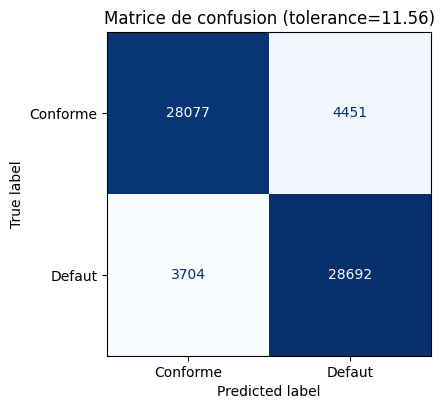


=== Test du Chi-2 ===
chi2 = 36418.68   dof = 1   p-value = 0
effectif minimum attendu = 15858.2 (doit etre >= 5 pour fiabilite)
-> Association significative (le modele bat le hasard).

=== Metriques (pos_label = 'Defaut', la classe qui compte le plus en QC) ===
R2 (validation croisee)  : 0.7422
Accuracy                 : 0.8744
F1-score                 : 0.8756
Recall (rappel)          : 0.8857
Precision                : 0.8657

=== Rapport de classification complet ===
              precision    recall  f1-score   support

    Conforme       0.88      0.86      0.87     32528
      Defaut       0.87      0.89      0.88     32396

    accuracy                           0.87     64924
   macro avg       0.87      0.87      0.87     64924
weighted avg       0.87      0.87      0.87     64924



In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
)
from scipy.stats import chi2_contingency

# --- 1) Choix de la tolerance de conformite -------------------------------
# La distorsion est une valeur CONTINUE : pour calculer une matrice de
# confusion / accuracy / F1 / recall, il faut d'abord la transformer en
# decision binaire Conforme / Defaut via une tolerance metier.
abs_y = train[Y_COLS].abs().stack().dropna()
print("Distribution de |distorsion optique| (toutes cibles, apres nettoyage outliers) :")
print(abs_y.describe().round(3))
print("\nPercentiles :", abs_y.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_dict())

# Valeur par defaut = mediane reelle des donnees (garantit un partage non
# degenere Conforme/Defaut). A REMPLACER par la vraie tolerance qualite du
# cahier des charges des que vous la connaissez.
TOLERANCE = float(abs_y.median())
print(f"\nTOLERANCE utilisee : {TOLERANCE:.3f}  <-- a remplacer par la vraie tolerance metier si connue")

# --- 2) Matrice de confusion (a partir des predictions out-of-fold) -------
all_true, all_pred = [], []
for col in Y_COLS:
    mask = oof_pred[col].notna() & train[col].notna()
    y_true_cls = (train.loc[mask, col].abs() <= TOLERANCE).map({True: "Conforme", False: "Defaut"})
    y_pred_cls = (oof_pred[col][mask].abs() <= TOLERANCE).map({True: "Conforme", False: "Defaut"})
    all_true += list(y_true_cls)
    all_pred += list(y_pred_cls)

cm = confusion_matrix(all_true, all_pred, labels=["Conforme", "Defaut"])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Conforme", "Defaut"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion (tolerance={TOLERANCE:.2f})")
plt.tight_layout()
plt.show()

if cm.min() == 0 and (cm.sum(axis=0) == 0).any() or (cm.sum(axis=1) == 0).any():
    print("\n⚠️ Une des deux classes est absente (matrice degeneree) : ajustez TOLERANCE "
          "ci-dessus (voir les percentiles) avant d'interpreter les metriques.")

# --- 3) Test du Chi-2 : le modele fait-il mieux que le hasard ? ----------
try:
    chi2, p_value, dof, expected = chi2_contingency(cm)
    print(f"\n=== Test du Chi-2 ===")
    print(f"chi2 = {chi2:.2f}   dof = {dof}   p-value = {p_value:.3g}")
    print(f"effectif minimum attendu = {expected.min():.1f} (doit etre >= 5 pour fiabilite)")
    print("-> Association significative (le modele bat le hasard)." if p_value < 0.05
          else "-> Association NON significative.")
except ValueError:
    print("\nChi-2 non calculable : matrice de confusion degeneree (une seule classe presente). "
          "Ajustez TOLERANCE ci-dessus.")

# --- 4) R2, Accuracy, F1, Recall -------------------------------------------
r2_global = fold_df["R2_val"].mean()  # cf. cellule de validation croisee ci-dessus

print(f"\n=== Metriques (pos_label = 'Defaut', la classe qui compte le plus en QC) ===")
print(f"R2 (validation croisee)  : {r2_global:.4f}")
print(f"Accuracy                 : {accuracy_score(all_true, all_pred):.4f}")
print(f"F1-score                 : {f1_score(all_true, all_pred, pos_label='Defaut'):.4f}")
print(f"Recall (rappel)          : {recall_score(all_true, all_pred, pos_label='Defaut'):.4f}")
print(f"Precision                : {precision_score(all_true, all_pred, pos_label='Defaut'):.4f}")

print("\n=== Rapport de classification complet ===")
print(classification_report(all_true, all_pred, target_names=["Conforme", "Defaut"]))